In [1]:
import pandas as pd
print("Notebook Ready")

Notebook Ready


In [3]:
import streamlit
print("Streamlit Ready")

Streamlit Ready


In [4]:
import pandas, numpy, sklearn, matplotlib, seaborn
print("Core packages good")

Core packages good


In [6]:
import xgboost
print("xgboost ready")


xgboost ready


In [7]:
import shap
print("shap ready")

shap ready


In [8]:
import pandas as pd
df = pd.read_csv("../data/Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# EDA

In [12]:
df.shape

(374, 13)

In [13]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [15]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [16]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

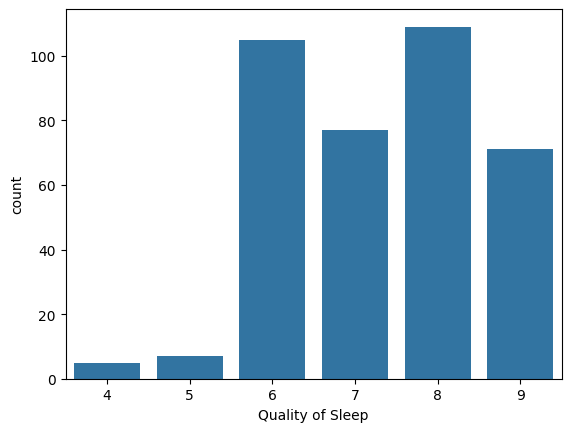

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Quality of Sleep", data=df)
plt.show()

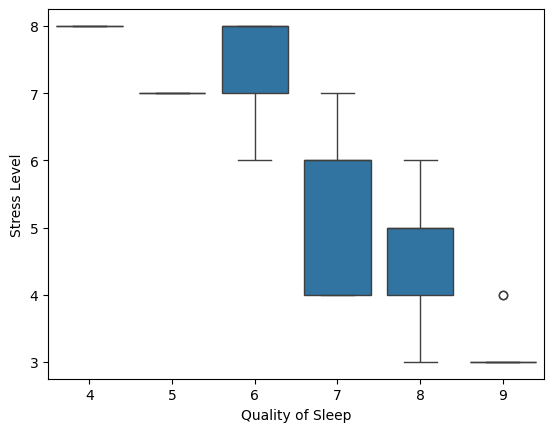

In [18]:
sns.boxplot(x="Quality of Sleep", y="Stress Level", data=df)
plt.show()

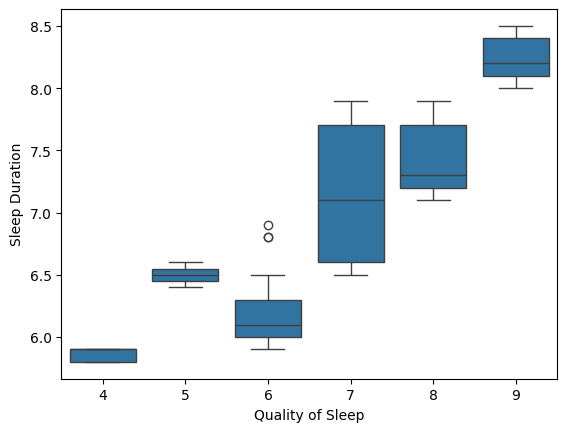

In [19]:
sns.boxplot(x="Quality of Sleep", y="Sleep Duration", data=df)
plt.show()

In [20]:
import pandas as pd
import numpy as np

# Load original dataset
df = pd.read_csv("../data/Sleep_health_and_lifestyle_dataset.csv")

# Reproducible random values
np.random.seed(42)

# Number of rows
n = len(df)

# -----------------------------
# Add Synthetic Features
# -----------------------------

# Screen time before bed (hours)
df["Screen_Time_Before_Bed"] = np.round(np.random.uniform(0.2, 4.0, n), 1)

# Caffeine cups per day
df["Caffeine_Cups_Per_Day"] = np.random.randint(0, 6, n)

# Bedtime consistency (days/week same bedtime)
df["Bedtime_Consistency"] = np.random.randint(1, 8, n)

# Wake-up consistency (days/week same wake time)
df["Wakeup_Consistency"] = np.random.randint(1, 8, n)

# Water intake liters/day
df["Water_Intake_Liters"] = np.round(np.random.uniform(1.0, 4.5, n), 1)

# Weekend oversleep difference (hours)
df["Weekend_Sleep_Debt"] = np.round(np.random.uniform(0.0, 3.0, n), 1)

# -----------------------------
# Improve realism using logic
# -----------------------------

# High stress people usually more screen time
if "Stress Level" in df.columns:
    df["Screen_Time_Before_Bed"] += (df["Stress Level"] / 10)

# Poor sleep duration may correlate with more caffeine
if "Sleep Duration" in df.columns:
    df["Caffeine_Cups_Per_Day"] += np.where(df["Sleep Duration"] < 6.5, 1, 0)

# Keep clean ranges
df["Screen_Time_Before_Bed"] = df["Screen_Time_Before_Bed"].clip(0.2, 5.0).round(1)
df["Caffeine_Cups_Per_Day"] = df["Caffeine_Cups_Per_Day"].clip(0, 6)

# -----------------------------
# Save upgraded dataset
# -----------------------------
df.to_csv("../data/upgraded_sleep_dataset.csv", index=False)

print("Upgraded dataset created successfully!")
df.head()

Upgraded dataset created successfully!


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Screen_Time_Before_Bed,Caffeine_Cups_Per_Day,Bedtime_Consistency,Wakeup_Consistency,Water_Intake_Liters,Weekend_Sleep_Debt
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,2.2,1,7,2,1.4,2.4
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,4.6,2,1,1,1.3,1.8
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,3.8,5,6,3,3.4,2.6
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,3.3,2,7,7,2.2,0.6
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1.6,2,6,4,3.5,0.3


In [21]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Screen_Time_Before_Bed', 'Caffeine_Cups_Per_Day',
       'Bedtime_Consistency', 'Wakeup_Consistency', 'Water_Intake_Liters',
       'Weekend_Sleep_Debt'],
      dtype='str')

In [22]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Screen_Time_Before_Bed,Caffeine_Cups_Per_Day,Bedtime_Consistency,Wakeup_Consistency,Water_Intake_Liters,Weekend_Sleep_Debt
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,2.2,1,7,2,1.4,2.4
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,4.6,2,1,1,1.3,1.8
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,3.8,5,6,3,3.4,2.6
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,3.3,2,7,7,2.2,0.6
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,1.6,2,6,4,3.5,0.3


In [23]:
df.shape

(374, 19)

In [24]:
def label_sleep(score):
    if score <= 4:
        return "Poor"
    elif score <= 7:
        return "Moderate"
    else:
        return "Good"

df["Sleep_Category"] = df["Quality of Sleep"].apply(label_sleep)

In [25]:
df[["Quality of Sleep", "Sleep_Category"]].head(10)

,Quality of Sleep,Sleep_Category
0,6,Moderate
1,6,Moderate
2,6,Moderate
3,4,Poor
4,4,Poor
5,4,Poor
6,6,Moderate
7,7,Moderate
8,7,Moderate
9,7,Moderate


In [26]:
df["Sleep_Category"].value_counts()

Sleep_Category
Moderate    189
Good        180
Poor          5
Name: count, dtype: int64

In [27]:
def label_sleep(score):
    if score <= 5:
        return "Poor"
    elif score <= 7:
        return "Moderate"
    else:
        return "Good"

df["Sleep_Category"] = df["Quality of Sleep"].apply(label_sleep)

df["Sleep_Category"].value_counts()

Sleep_Category
Moderate    182
Good        180
Poor         12
Name: count, dtype: int64

In [28]:
import numpy as np

# Start with neutral score
score = np.full(len(df), 5.0)

# ---------------------------
# Positive Contributions
# ---------------------------

# Sleep Duration (best around 7 to 8 hrs)
score += np.where(df["Sleep Duration"].between(7, 8), 2.0, 0.5)

# Physical Activity
score += (df["Physical Activity Level"] / 100)

# Bedtime consistency
score += (df["Bedtime_Consistency"] / 10)

# Water intake
score += (df["Water_Intake_Liters"] / 5)

# ---------------------------
# Negative Contributions
# ---------------------------

# Stress level
score -= (df["Stress Level"] / 5)

# Screen time before bed
score -= (df["Screen_Time_Before_Bed"] / 2)

# Caffeine intake
score -= (df["Caffeine_Cups_Per_Day"] / 3)

# Weekend sleep debt
score -= (df["Weekend_Sleep_Debt"] / 2)

# ---------------------------
# Final Clean Score
# ---------------------------

df["Custom_Sleep_Score"] = np.clip(score, 1, 10).round(1)

df[["Quality of Sleep", "Custom_Sleep_Score"]].head()

,Quality of Sleep,Custom_Sleep_Score
0,6,3.1
1,6,1.0
2,6,1.0
3,4,2.7
4,4,3.9


In [29]:
score = np.full(len(df), 6.0)

# Positive
score += np.where(df["Sleep Duration"].between(7, 8), 2.0, 0.8)
score += (df["Physical Activity Level"] / 150)
score += (df["Bedtime_Consistency"] / 12)
score += (df["Water_Intake_Liters"] / 8)

# Negative (lighter)
score -= (df["Stress Level"] / 8)
score -= (df["Screen_Time_Before_Bed"] / 4)
score -= (df["Caffeine_Cups_Per_Day"] / 5)
score -= (df["Weekend_Sleep_Debt"] / 4)

df["Custom_Sleep_Score"] = np.clip(score, 1, 10).round(1)

df[["Quality of Sleep", "Custom_Sleep_Score"]].head(10)

,Quality of Sleep,Custom_Sleep_Score
0,6,5.7
1,6,4.4
2,6,4.5
3,4,5.5
4,4,6.1
5,4,5.4
6,6,5.5
7,7,6.9
8,7,6.4
9,7,7.3


In [30]:
def custom_label(score):
    if score < 5:
        return "Poor"
    elif score < 7:
        return "Moderate"
    else:
        return "Good"

df["Custom_Sleep_Category"] = df["Custom_Sleep_Score"].apply(custom_label)

df["Custom_Sleep_Category"].value_counts()

Custom_Sleep_Category
Moderate    228
Good         96
Poor         50
Name: count, dtype: int64

In [31]:
import numpy as np

score = np.full(len(df), 5.5)

# -------------------------
# Sleep Duration (best 7-8)
# -------------------------
sleep = df["Sleep Duration"]

score += np.where(sleep.between(7, 8), 2.2,
         np.where(sleep.between(6, 9), 1.0, -1.0))

# -------------------------
# Stress (nonlinear penalty)
# -------------------------
stress = df["Stress Level"]

score -= np.where(stress >= 8, 2.0,
         np.where(stress >= 6, 1.2,
         np.where(stress >= 4, 0.6, 0.2)))

# -------------------------
# Screen Time Before Bed
# -------------------------
screen = df["Screen_Time_Before_Bed"]

score -= np.where(screen > 3, 1.5,
         np.where(screen > 2, 1.0,
         np.where(screen > 1, 0.5, 0.1)))

# -------------------------
# Caffeine Intake
# -------------------------
caf = df["Caffeine_Cups_Per_Day"]

score -= np.where(caf >= 5, 1.5,
         np.where(caf >= 3, 1.0,
         np.where(caf >= 1, 0.4, 0.0)))

# -------------------------
# Physical Activity
# -------------------------
activity = df["Physical Activity Level"]

score += np.where(activity >= 60, 1.2,
         np.where(activity >= 30, 0.7, 0.2))

# -------------------------
# Bedtime + Wakeup Consistency
# -------------------------
score += (df["Bedtime_Consistency"] + df["Wakeup_Consistency"]) / 18

# -------------------------
# Water Intake
# -------------------------
score += np.where(df["Water_Intake_Liters"] >= 2.5, 0.5, 0.1)

# -------------------------
# Weekend Sleep Debt
# -------------------------
score -= np.where(df["Weekend_Sleep_Debt"] > 2, 1.0,
         np.where(df["Weekend_Sleep_Debt"] > 1, 0.5, 0.1))

# Final Score
df["Custom_Sleep_Score"] = np.clip(score, 1, 10).round(1)

df[["Quality of Sleep", "Custom_Sleep_Score"]].head(10)

,Quality of Sleep,Custom_Sleep_Score
0,6,4.2
1,6,3.5
2,6,2.7
3,4,2.1
4,4,3.3
5,4,2.5
6,6,4.5
7,7,6.2
8,7,5.7
9,7,6.4


In [32]:
score = np.full(len(df), 6.0)

# Sleep duration
score += np.where(df["Sleep Duration"].between(7, 8), 2.0, 0.8)

# Positive
score += (df["Physical Activity Level"] / 170)
score += (df["Bedtime_Consistency"] / 14)
score += (df["Water_Intake_Liters"] / 10)

# Moderate penalties
score -= (df["Stress Level"] / 7)
score -= (df["Screen_Time_Before_Bed"] / 5)
score -= (df["Caffeine_Cups_Per_Day"] / 6)
score -= (df["Weekend_Sleep_Debt"] / 5)

df["Custom_Sleep_Score"] = np.clip(score, 1, 10).round(1)

df[["Quality of Sleep", "Custom_Sleep_Score"]].head(10)

,Quality of Sleep,Custom_Sleep_Score
0,6,5.7
1,6,4.6
2,6,4.7
3,4,5.4
4,4,5.9
5,4,5.4
6,6,5.5
7,7,6.9
8,7,6.5
9,7,7.2


In [33]:
# Features (X)
X = df.drop(columns=[
    "Quality of Sleep",
    "Sleep_Category",
    "Custom_Sleep_Score",
    "Custom_Sleep_Category"
], errors="ignore")

# Target (y)
y = df["Quality of Sleep"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (374, 18)
y shape: (374,)


In [34]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Person ID,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Screen_Time_Before_Bed,Caffeine_Cups_Per_Day,Bedtime_Consistency,...,Blood Pressure_130/86,Blood Pressure_131/86,Blood Pressure_132/87,Blood Pressure_135/88,Blood Pressure_135/90,Blood Pressure_139/91,Blood Pressure_140/90,Blood Pressure_140/95,Blood Pressure_142/92,Sleep Disorder_Sleep Apnea
0,1,27,6.1,42,6,77,4200,2.2,1,7,...,False,False,False,False,False,False,False,False,False,False
1,2,28,6.2,60,8,75,10000,4.6,2,1,...,False,False,False,False,False,False,False,False,False,False
2,3,28,6.2,60,8,75,10000,3.8,5,6,...,False,False,False,False,False,False,False,False,False,False
3,4,28,5.9,30,8,85,3000,3.3,2,7,...,False,False,False,False,False,False,True,False,False,True
4,5,28,5.9,30,8,85,3000,1.6,2,6,...,False,False,False,False,False,False,True,False,False,True


In [35]:
# Select only realistic user-input columns

X = df[[
    "Age",
    "Sleep Duration",
    "Stress Level",
    "Physical Activity Level",
    "Screen_Time_Before_Bed",
    "Caffeine_Cups_Per_Day",
    "Bedtime_Consistency",
    "Wakeup_Consistency",
    "Water_Intake_Liters",
    "Weekend_Sleep_Debt",
    "Gender"
]]

# Target
y = df["Quality of Sleep"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (374, 11)
y shape: (374,)


In [36]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,Sleep Duration,Stress Level,Physical Activity Level,Screen_Time_Before_Bed,Caffeine_Cups_Per_Day,Bedtime_Consistency,Wakeup_Consistency,Water_Intake_Liters,Weekend_Sleep_Debt,Gender_Male
0,27,6.1,6,42,2.2,1,7,2,1.4,2.4,True
1,28,6.2,8,60,4.6,2,1,1,1.3,1.8,True
2,28,6.2,8,60,3.8,5,6,3,3.4,2.6,True
3,28,5.9,8,30,3.3,2,7,7,2.2,0.6,True
4,28,5.9,8,30,1.6,2,6,4,3.5,0.3,True


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(299, 11) (75, 11)


# Train Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", round(mean_absolute_error(y_test, pred_lr), 2))
print("R2:", round(r2_score(y_test, pred_lr), 2))

Linear Regression
MAE: 0.33
R2: 0.88


# Train Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", round(mean_absolute_error(y_test, pred_rf), 2))
print("R2:", round(r2_score(y_test, pred_rf), 2))

Random Forest
MAE: 0.07
R2: 0.97


# Train XGBoost

In [40]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("MAE:", round(mean_absolute_error(y_test, pred_xgb), 2))
print("R2:", round(r2_score(y_test, pred_xgb), 2))

XGBoost
MAE: 0.05
R2: 0.98


# XGboost better, save ---X

In [41]:
import joblib

joblib.dump(xgb, "../models/sleep_model.pkl")
joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

print("Model saved")

Model saved


In [43]:
def score_to_category(score):
    if score <= 5:
        return "Poor"
    elif score < 8:
        return "Moderate"
    else:
        return "Good"

In [44]:
print(score_to_category(4.8))
print(score_to_category(6.9))
print(score_to_category(8.2))

Poor
Moderate
Good


In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average R2:", scores.mean())

[-0.07575333  0.41152889  0.8572982   0.82899308  0.84522748]
Average R2: 0.5734588623046875


In [46]:
scores_rf = cross_val_score(rf, X, y, cv=5, scoring="r2")
print(scores_rf)
print(scores_rf.mean())

[0.42381175 0.74692714 0.80205174 0.78116516 0.78370145]
0.707531448218111


# Random forest better, save

In [47]:
import joblib

joblib.dump(rf, "../models/sleep_model.pkl")
joblib.dump(X.columns.tolist(), "../models/model_columns.pkl")

print("Random Forest model saved")

Random Forest model saved
